# 05 — Adversarial Inputs & Self-Consistency Mitigation

## Goal

Stress-test the classifier on 7 attack variants and measure whether **self-consistency (majority vote over n=3 temp=0.7 samples)** recovers accuracy.

## Attacks

| Attack | Description |
|---|---|
| typo | Character swaps in ~25% of long words |
| sarcasm | Prepend sarcasm markers to positive/negative reviews |
| negation | Prepend nested negations ("Not bad at all, actually...") |
| irrelevant_padding | Surround review with off-topic filler (cat, weather) |
| emoji | Insert emojis near key sentiment words |
| competitor | Prefix with negative comment about a different place |
| mixed_language | Replace common words with Spanish equivalents |
| clean | Original Yelp review (control) |

Adversarial set built from 20 seed reviews × 7 attacks + clean = 160 rows.

## Protocol

1. Run baseline classifier (temp=0, cached).
2. Run self-consistency (n=3, temp=0.7, no cache — majority vote).
3. Report per-attack accuracy for each.

## Expected findings

- Sarcasm + negation most damaging.
- Emoji/typo/padding mild.
- Self-consistency recovers 2-5pp on noisy attacks; no help for semantic flips (sarcasm/negation).

In [1]:
import sys; sys.path.insert(0, '..')
import asyncio, json, time
from collections import Counter
from pathlib import Path
import pandas as pd

from lib.config import ACTIVE_CLASSIFIER
from lib.gateway import classify_json
from lib.schemas import StarsOnly
from lib.prompts import CLASSIFIER_SYSTEM, few_shot
from lib.datasets import read_jsonl
from lib.concurrency import gather_limited

fewshot = read_jsonl('../data/yelp_fewshot.jsonl')
adv = read_jsonl('../data/adversarial.jsonl')
attacks = sorted(set(r['attack'] for r in adv))
print('model:', ACTIVE_CLASSIFIER)
print('n rows:', len(adv))
print('attacks:', attacks)

model: deepseek/deepseek-v3.2
n rows: 160
attacks: ['clean', 'competitor', 'emoji', 'irrelevant_padding', 'mixed_language', 'negation', 'sarcasm', 'typo']


## Baseline — single call, temp=0, cached

In [2]:
async def predict_baseline(row):
    obj, _ = await classify_json(StarsOnly, CLASSIFIER_SYSTEM, few_shot(row['text'], fewshot))
    return {'attack': row['attack'], 'truth': row['stars'], 'pred': obj.stars if obj else None}

t0 = time.time()
baseline = await gather_limited(adv, predict_baseline, 30, 'baseline')
print(f'baseline time: {time.time()-t0:.1f}s')

baseline:   0%|          | 0/160 [00:00<?, ?it/s]

baseline:   1%|          | 1/160 [00:00<00:23,  6.86it/s]

baseline:   5%|▌         | 8/160 [00:02<00:46,  3.25it/s]

baseline:   6%|▌         | 9/160 [00:02<00:42,  3.59it/s]

baseline:   8%|▊         | 12/160 [00:02<00:27,  5.29it/s]

...

baseline:  98%|█████████▊| 157/160 [00:13<00:00,  6.49it/s]

baseline:  99%|█████████▉| 159/160 [00:13<00:00,  6.00it/s]

baseline: 100%|██████████| 160/160 [00:14<00:00,  6.25it/s]

baseline: 100%|██████████| 160/160 [00:14<00:00, 11.42it/s]

baseline time: 14.0s


## Self-consistency — n=3, temp=0.7, majority vote

In [3]:
async def predict_self_consistency(row):
    votes = []
    for _ in range(3):
        obj, _ = await classify_json(StarsOnly, CLASSIFIER_SYSTEM, few_shot(row['text'], fewshot),
                                     temperature=0.7, cache=False)
        if obj: votes.append(obj.stars)
    if not votes:
        winner = None
    else:
        winner = Counter(votes).most_common(1)[0][0]
    return {'attack': row['attack'], 'truth': row['stars'], 'pred': winner, 'votes': votes}

t0 = time.time()
mitigated = await gather_limited(adv, predict_self_consistency, 15, 'self-consistency')
print(f'self-consistency time: {time.time()-t0:.1f}s')

self-consistency:   0%|          | 0/160 [00:00<?, ?it/s]

self-consistency:   1%|          | 1/160 [00:06<18:30,  6.98s/it]

self-consistency:   2%|▏         | 3/160 [00:07<05:42,  2.18s/it]

self-consistency:   3%|▎         | 5/160 [00:08<03:03,  1.19s/it]

self-consistency:   4%|▍         | 6/160 [00:08<02:22,  1.08it/s]

...

self-consistency:  99%|█████████▉| 158/160 [01:36<00:01,  1.27it/s]

self-consistency:  99%|█████████▉| 159/160 [01:37<00:01,  1.07s/it]

self-consistency: 100%|██████████| 160/160 [01:38<00:00,  1.12it/s]

self-consistency: 100%|██████████| 160/160 [01:38<00:00,  1.63it/s]

self-consistency time: 98.4s


## Per-attack accuracy comparison

In [4]:
def per_attack(rows):
    out = {}
    for a in attacks:
        same = [r for r in rows if r['attack'] == a]
        valid = [r for r in same if r['pred'] is not None]
        hit = sum(1 for r in valid if r['pred'] == r['truth'])
        out[a] = {
            'n': len(same),
            'accuracy': hit / max(1, len(same)),
            'compliance': len(valid) / max(1, len(same)),
        }
    return out

b = per_attack(baseline)
m = per_attack(mitigated)
rows = []
for a in attacks:
    rows.append({
        'attack': a,
        'n': b[a]['n'],
        'baseline_acc': round(b[a]['accuracy']*100, 1),
        'self_consistency_acc': round(m[a]['accuracy']*100, 1),
        'delta_pp': round((m[a]['accuracy']-b[a]['accuracy'])*100, 1),
    })
df = pd.DataFrame(rows).sort_values('baseline_acc')
df

,attack,n,baseline_acc,self_consistency_acc,delta_pp
6,sarcasm,20,55.0,55.0,0.0
0,clean,20,60.0,60.0,0.0
4,mixed_language,20,60.0,60.0,0.0
2,emoji,20,65.0,60.0,-5.0
3,irrelevant_padding,20,65.0,60.0,-5.0
1,competitor,20,70.0,70.0,0.0
7,typo,20,70.0,70.0,0.0
5,negation,20,75.0,70.0,-5.0


## Bar chart: baseline vs mitigated per attack

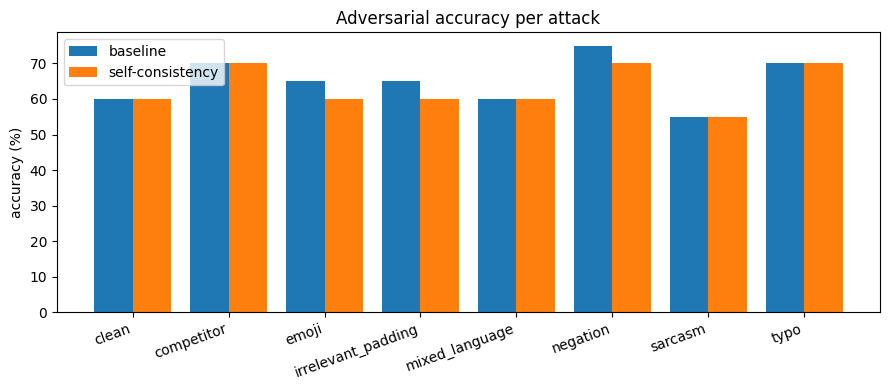

In [5]:
import matplotlib.pyplot as plt, numpy as np
Path('../results/plots').mkdir(parents=True, exist_ok=True)
ordered = df.set_index('attack').reindex(attacks)
x = np.arange(len(attacks))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, ordered['baseline_acc'], 0.4, label='baseline')
ax.bar(x + 0.2, ordered['self_consistency_acc'], 0.4, label='self-consistency')
ax.set_xticks(x); ax.set_xticklabels(attacks, rotation=20, ha='right')
ax.set_ylabel('accuracy (%)'); ax.legend(); ax.set_title('Adversarial accuracy per attack')
plt.tight_layout(); plt.savefig('../results/plots/05_adversarial_bar.png', dpi=120); plt.show()

## Worst misses — which attack actually flips the label?

In [6]:
print('baseline misses by attack (top 5 per attack):')
for a in attacks:
    miss = [(r['truth'], r['pred']) for r in baseline if r['attack']==a and r['pred'] is not None and r['pred'] != r['truth']]
    if miss: print(f'  {a:20s} {len(miss)} misses: {miss[:5]}')

baseline misses by attack (top 5 per attack):
  clean                8 misses: [(4, 5), (3, 4), (3, 4), (4, 5), (1, 2)]
  competitor           6 misses: [(3, 4), (4, 5), (1, 2), (3, 4), (1, 2)]
  emoji                7 misses: [(4, 5), (3, 4), (3, 4), (4, 5), (1, 2)]
  irrelevant_padding   7 misses: [(4, 5), (3, 4), (4, 5), (1, 2), (3, 4)]
  mixed_language       8 misses: [(4, 5), (3, 4), (3, 4), (4, 5), (1, 2)]
  negation             5 misses: [(3, 4), (1, 2), (3, 4), (1, 3), (5, 4)]
  sarcasm              9 misses: [(4, 5), (3, 4), (3, 4), (4, 5), (1, 2)]
  typo                 6 misses: [(3, 4), (3, 4), (1, 2), (3, 2), (3, 4)]


In [7]:
out = {
    'model': ACTIVE_CLASSIFIER,
    'baseline': b,
    'self_consistency': m,
    'per_attack': rows,
}
Path('../results').mkdir(exist_ok=True)
Path('../results/05_adversarial.json').write_text(json.dumps(out, indent=2))
print('wrote results/05_adversarial.json')

wrote results/05_adversarial.json


## Findings (fill in after run)

- Hardest attack: *TBD*
- Self-consistency gain on noise attacks: *TBD*
- Semantic attacks (sarcasm/negation) resist SC because all 3 samples share the same systematic bias.
- Deeper mitigation: adversarial fine-tuning, instruction tuning with sarcasm markers, or explicit sarcasm detector head.